# FASE 0 — Exploración del Dataset DermaMNIST
Antes de construir cualquier modelo, entendemos con qué datos trabajamos.

In [2]:
import sys
!{sys.executable} -m pip install medmnist monai scikit-learn matplotlib numpy torch torchvision -q
print("Instalacion completada.")

Instalacion completada.


"c:\Users\isape\OneDrive\Escritorio\ANALITICA\DL" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## 1. Verificación del entorno

In [3]:
import torch
import monai
import medmnist

print('='*45)
print(f'PyTorch  : {torch.__version__}')
print(f'MONAI    : {monai.__version__}')
print(f'MedMNIST : {medmnist.__version__}')
print('='*45)

if torch.cuda.is_available():
    print(f'✅ GPU detectada : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  GPU NO detectada — revisar instalación de CUDA')

PyTorch  : 2.5.1+cu118
MONAI    : 1.4.0
MedMNIST : 3.0.2
✅ GPU detectada : NVIDIA GeForce RTX 3050 6GB Laptop GPU
   VRAM          : 6.4 GB


## 2. Descarga y carga del dataset

In [4]:
import medmnist
from medmnist import DermaMNIST, INFO
from torch.utils.data import DataLoader
import numpy as np

# Info del dataset
info = INFO['dermamnist']
print('Dataset:', info['description'] if 'description' in info else 'DermaMNIST')
print('Tarea  :', info['task'])
print('Clases :', info['n_channels'], 'canales')
print()
print('Etiquetas:')
for k, v in info['label'].items():
    print(f'  {k}: {v}')

# Nombres de las 7 clases
CLASS_NAMES = list(info['label'].values())
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nTotal de clases: {NUM_CLASSES}')

Dataset: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
Tarea  : multi-class
Clases : 3 canales

Etiquetas:
  0: actinic keratoses and intraepithelial carcinoma
  1: basal cell carcinoma
  2: benign keratosis-like lesions
  3: dermatofibroma
  4: melanoma
  5: melanocytic nevi
  6: vascular lesions

Total de clases: 7


In [6]:
from torchvision import transforms

# Transform básico solo para exploración (luego usaremos MONAI)
basic_transform = transforms.ToTensor()

# Descargar los 3 splits
train_dataset = DermaMNIST(split='train', transform=basic_transform, download=True)
val_dataset   = DermaMNIST(split='val',   transform=basic_transform, download=True)
test_dataset  = DermaMNIST(split='test',  transform=basic_transform, download=True)

print(f'Train : {len(train_dataset):>6,} imágenes')
print(f'Val   : {len(val_dataset):>6,} imágenes')
print(f'Test  : {len(test_dataset):>6,} imágenes')
print(f'Total : {len(train_dataset)+len(val_dataset)+len(test_dataset):>6,} imágenes')

100%|██████████| 19.7M/19.7M [01:36<00:00, 204kB/s] 


Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Train :  7,007 imágenes
Val   :  1,003 imágenes
Test  :  2,005 imágenes
Total : 10,015 imágenes


## 3. Análisis del desbalance de clases

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Contar samples por clase en cada split
def count_classes(dataset, n_classes):
    counts = np.zeros(n_classes, dtype=int)
    for _, label in dataset:
        counts[int(label)] += 1
    return counts

train_counts = count_classes(train_dataset, NUM_CLASSES)
val_counts   = count_classes(val_dataset,   NUM_CLASSES)
test_counts  = count_classes(test_dataset,  NUM_CLASSES)

print('Distribución por clase (TRAIN):')
print('-'*50)
for i, (name, count) in enumerate(zip(CLASS_NAMES, train_counts)):
    pct = count / train_counts.sum() * 100
    bar = '█' * int(pct / 1.5)
    print(f'  [{i}] {name:<30} {count:>5} ({pct:4.1f}%) {bar}')

ratio = train_counts.max() / train_counts.min()
print(f'\n⚠️  Ratio desbalance (max/min): {ratio:.1f}x')

C:\Users\isape\AppData\Local\Temp\ipykernel_26648\2470947447.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  counts[int(label)] += 1


Distribución por clase (TRAIN):
--------------------------------------------------
  [0] actinic keratoses and intraepithelial carcinoma   228 ( 3.3%) ██
  [1] basal cell carcinoma             359 ( 5.1%) ███
  [2] benign keratosis-like lesions    769 (11.0%) ███████
  [3] dermatofibroma                    80 ( 1.1%) 
  [4] melanoma                         779 (11.1%) ███████
  [5] melanocytic nevi                4693 (67.0%) ████████████████████████████████████████████
  [6] vascular lesions                  99 ( 1.4%) 

⚠️  Ratio desbalance (max/min): 58.7x


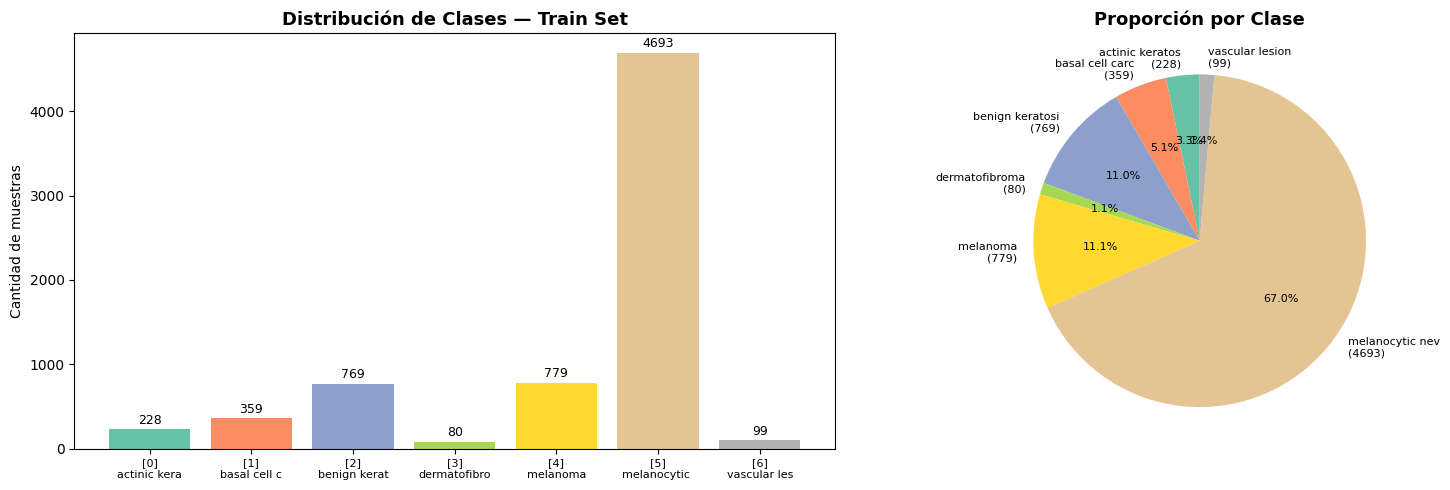

✅ Guardado: distribucion_clases.png


In [8]:
# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

# Barras
ax = axes[0]
bars = ax.bar(range(NUM_CLASSES), train_counts, color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([f'[{i}]\n{n[:12]}' for i, n in enumerate(CLASS_NAMES)], fontsize=8)
ax.set_title('Distribución de Clases — Train Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de muestras')
for bar, count in zip(bars, train_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=9)

# Pie chart
ax = axes[1]
ax.pie(train_counts, labels=[f'{n[:15]}\n({c})' for n, c in zip(CLASS_NAMES, train_counts)],
       colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax.set_title('Proporción por Clase', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: distribucion_clases.png')

## 4. Visualización de imágenes por clase

C:\Users\isape\AppData\Local\Temp\ipykernel_26648\3566716508.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = int(label)


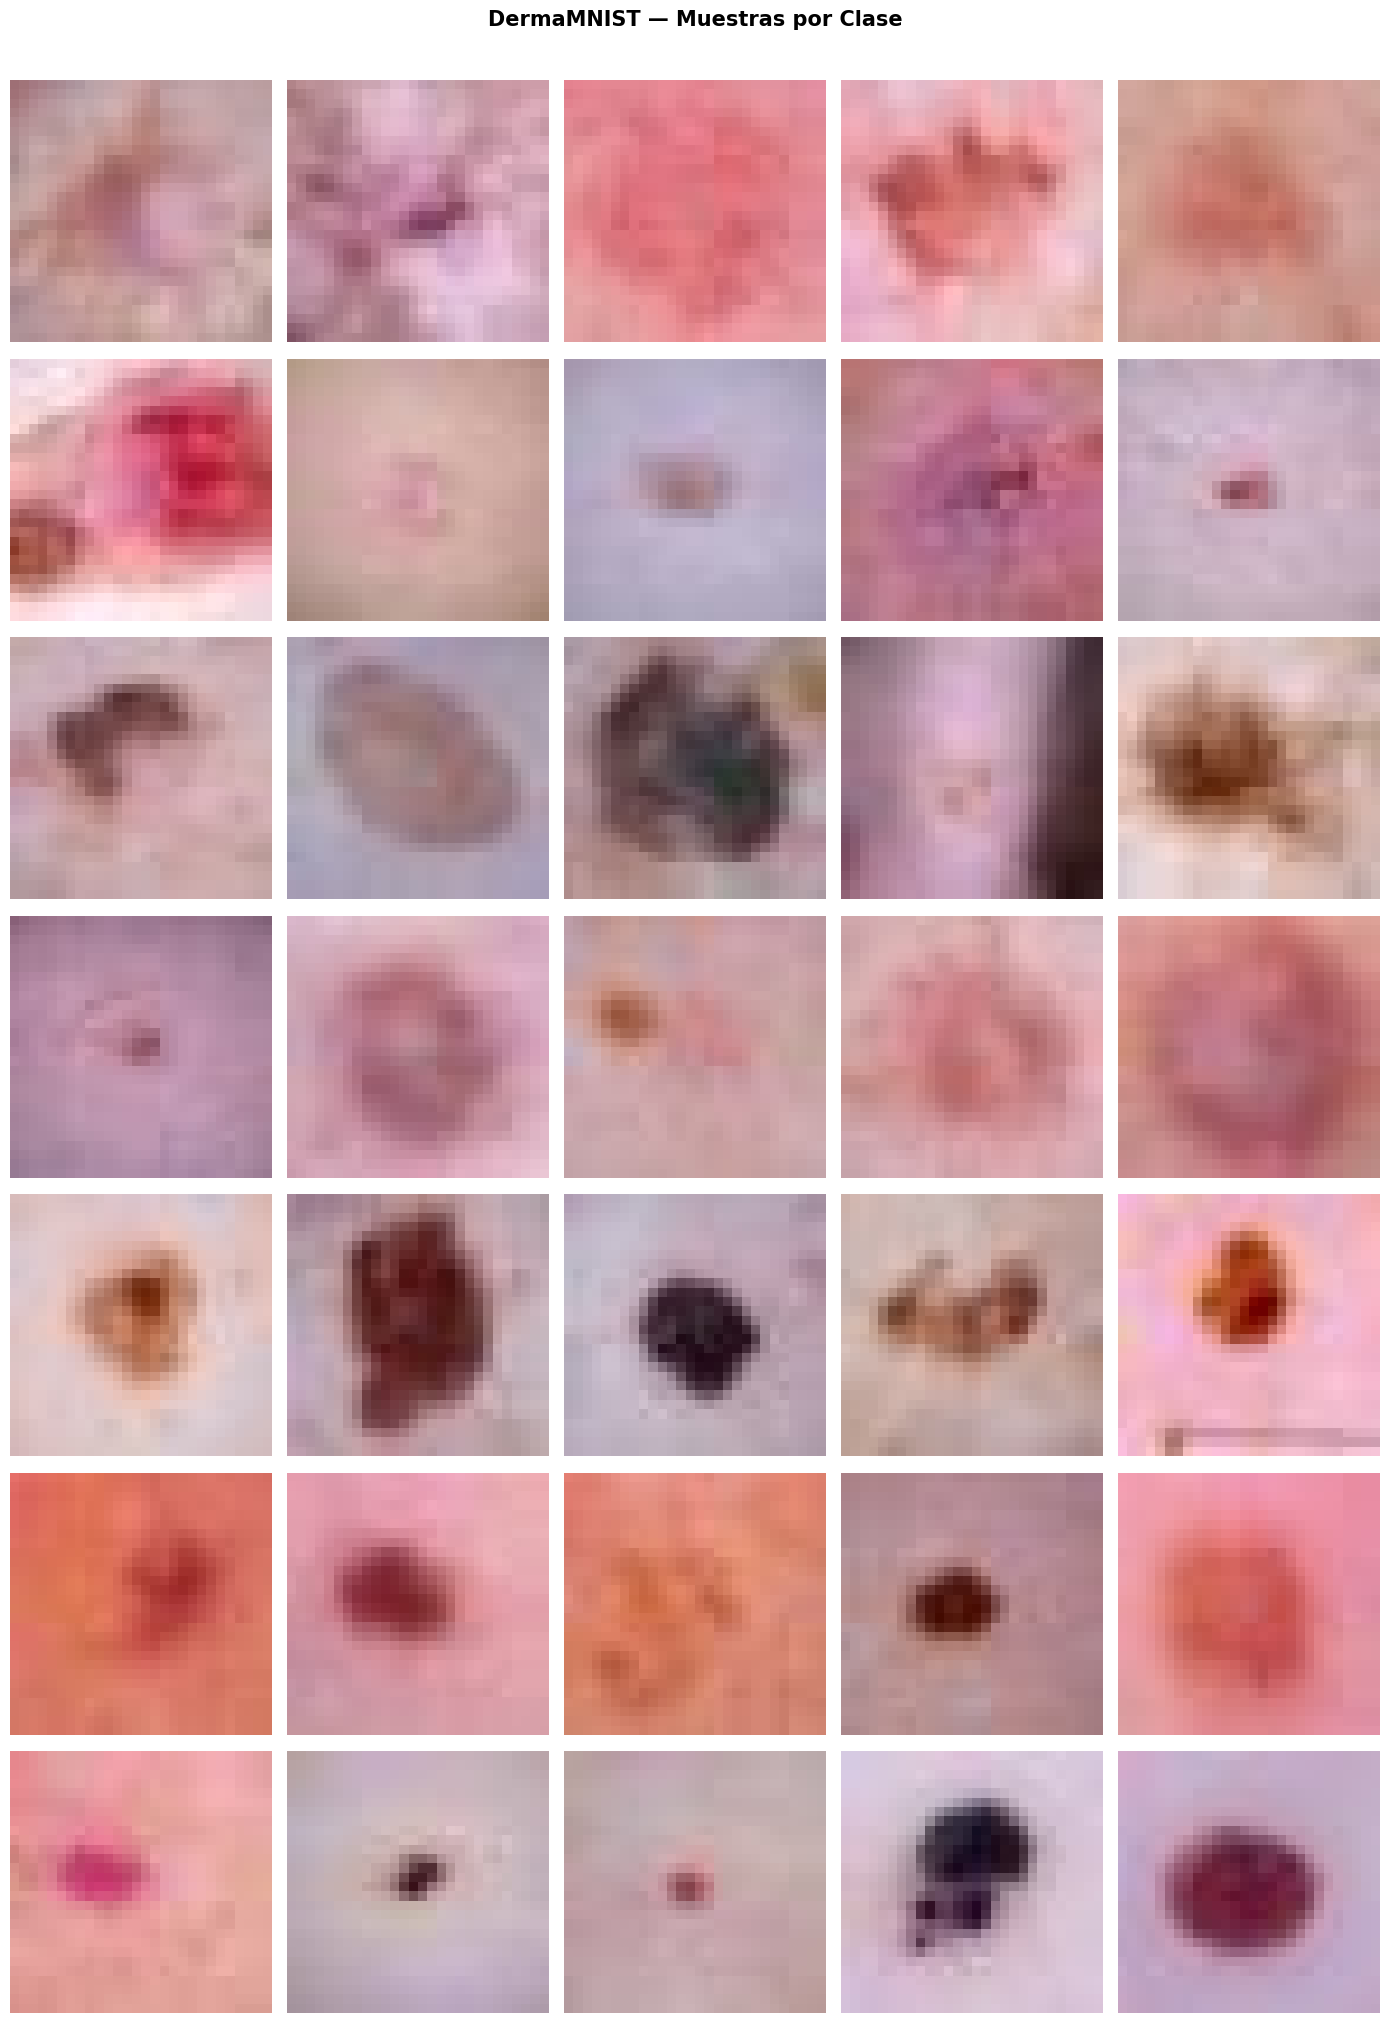

✅ Guardado: muestras_por_clase.png


In [9]:
# Mostrar 5 ejemplos de cada clase
SAMPLES_PER_CLASS = 5

# Agrupar índices por clase
class_indices = {i: [] for i in range(NUM_CLASSES)}
for idx, (_, label) in enumerate(train_dataset):
    c = int(label)
    if len(class_indices[c]) < SAMPLES_PER_CLASS:
        class_indices[c].append(idx)
    if all(len(v) == SAMPLES_PER_CLASS for v in class_indices.values()):
        break

fig, axes = plt.subplots(NUM_CLASSES, SAMPLES_PER_CLASS, figsize=(14, 20))
fig.suptitle('DermaMNIST — Muestras por Clase', fontsize=15, fontweight='bold', y=1.01)

for class_idx, indices in class_indices.items():
    for col, idx in enumerate(indices):
        img, _ = train_dataset[idx]
        img_np = img.permute(1, 2, 0).numpy()
        ax = axes[class_idx][col]
        ax.imshow(img_np)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'[{class_idx}] {CLASS_NAMES[class_idx][:18]}',
                         fontsize=9, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.savefig('muestras_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: muestras_por_clase.png')

## 5. Propiedades de las imágenes

In [12]:
# Tamaño, canales, rango de valores
img, label = train_dataset[0]
print(f'Shape de imagen : {img.shape}  (C x H x W)')
print(f'Tipo de dato    : {img.dtype}')
print(f'Rango valores   : [{img.min():.3f}, {img.max():.3f}]')
print(f'Resolución      : {img.shape[1]}x{img.shape[2]} px')

# Calcular media y std del train set (para normalización)
print('\nCalculando media y std del dataset (puede tardar ~1 min)...')
loader = DataLoader(train_dataset, batch_size=512, num_workers=0)
mean = torch.zeros(3)
std  = torch.zeros(3)
n = 0
for imgs, _ in loader:
    imgs = imgs.float()
    mean += imgs.mean(dim=[0,2,3]) * imgs.shape[0]
    std  += imgs.std(dim=[0,2,3])  * imgs.shape[0]
    n    += imgs.shape[0]
mean /= n
std  /= n

print(f'\n📊 Estadísticas del Train Set:')
print(f'   Media : R={mean[0]:.4f}  G={mean[1]:.4f}  B={mean[2]:.4f}')
print(f'   Std   : R={std[0]:.4f}  G={std[1]:.4f}  B={std[2]:.4f}')

Shape de imagen : torch.Size([3, 28, 28])  (C x H x W)
Tipo de dato    : torch.float32
Rango valores   : [0.365, 0.890]
Resolución      : 28x28 px

Calculando media y std del dataset (puede tardar ~1 min)...

📊 Estadísticas del Train Set:
   Media : R=0.7631  G=0.5381  B=0.5614
   Std   : R=0.1365  G=0.1542  B=0.1691


## 6. Cálculo de pesos para loss balanceada

In [14]:
# Pesos inversamente proporcionales a la frecuencia de clase
# Útil para CrossEntropyLoss(weight=class_weights)
total = train_counts.sum()
class_weights = total / (NUM_CLASSES * train_counts)
class_weights_tensor = torch.FloatTensor(class_weights)

print('Pesos por clase para loss balanceada:')
print('-'*45)
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f'  [{i}] {name:<30} peso: {w:.4f}')

print(f'\nclass_weights = {list(np.round(class_weights, 4))}')

Pesos por clase para loss balanceada:
---------------------------------------------
  [0] actinic keratoses and intraepithelial carcinoma peso: 4.3904
  [1] basal cell carcinoma           peso: 2.7883
  [2] benign keratosis-like lesions  peso: 1.3017
  [3] dermatofibroma                 peso: 12.5125
  [4] melanoma                       peso: 1.2850
  [5] melanocytic nevi               peso: 0.2133
  [6] vascular lesions               peso: 10.1111

class_weights = [4.3904, 2.7883, 1.3017, 12.5125, 1.285, 0.2133, 10.1111]
